# Notebook 12 – K-Means Clustering


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data.csv", encoding="latin1")
df = df.dropna(subset=["Description", "CustomerID"]).copy()
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

# Build a per-customer summary: this is the kind of table K-Means is naturally suited to cluster
customer_df = df.groupby("CustomerID").agg(
    TotalRevenue=("Revenue", "sum"),
    NumOrders=("InvoiceNo", "nunique"),
    AvgOrderValue=("Revenue", "mean"),
).reset_index()

# Keep only customers with positive revenue (excludes pure-return customers, kept simple for clustering)
customer_df = customer_df[customer_df["TotalRevenue"] > 0].copy()
customer_df.head()

,CustomerID,TotalRevenue,NumOrders,AvgOrderValue
1,12347.0,4310.00,7,23.681319
2,12348.0,1797.24,4,57.975484
3,12349.0,1757.55,1,24.076027
4,12350.0,334.40,1,19.670588
5,12352.0,1545.41,11,16.267474


## K-Means

**What it is:** the most widely used clustering algorithm. Given a number
of clusters `K` (chosen up front), K-Means groups data points into `K`
clusters by repeatedly assigning each point to its nearest cluster center,
then moving that center to the middle of the points now assigned to it —
alternating between those two steps until the clusters stop changing.

## Centroids

**What it is:** the "center point" of a cluster — literally the average
position of every point currently assigned to it. K-Means represents each
cluster by nothing more than its centroid; a new point is assigned to
whichever cluster's centroid it's closest to. Centroids are not real data
points — they're computed averages, and can land anywhere in feature
space, including a spot where no actual customer sits.

## Distance

**What it is:** how K-Means measures "closest." By default, it uses
ordinary straight-line (Euclidean) distance between a point and each
centroid. This is exactly why **feature scaling matters here too** (as it
did for SVM in Notebook 10): if `TotalRevenue` ranges into the tens of
thousands while `NumOrders` ranges from 1 to a few hundred, distance
calculations will be almost entirely dominated by `TotalRevenue`,
regardless of how meaningful `NumOrders` actually is.

In [2]:
from sklearn.preprocessing import StandardScaler

feature_cols = ["TotalRevenue", "NumOrders", "AvgOrderValue"]
print("Feature ranges BEFORE scaling:")
print(customer_df[feature_cols].describe().loc[["min", "max"]].round(2))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(customer_df[feature_cols])

print("\nFeature ranges AFTER scaling:")
print(pd.DataFrame(X_scaled, columns=feature_cols).describe().loc[["min", "max"]].round(2))

Feature ranges BEFORE scaling:
     TotalRevenue  NumOrders  AvgOrderValue
min          0.00        1.0            0.0
max     279489.02      248.0         3861.0

Feature ranges AFTER scaling:
     TotalRevenue  NumOrders  AvgOrderValue
min         -0.23      -0.44          -0.30
max         33.59      25.88          36.51


## Cluster Assignment & Centroid Update

**What they are:** the two alternating steps K-Means repeats until it
converges:

1. **Cluster Assignment** — every point is assigned to whichever
   centroid is currently closest to it.
2. **Centroid Update** — each centroid is recalculated as the average
   position of all the points now assigned to it.

Below, these two steps are implemented by hand (rather than relying on
scikit-learn) for one small, easy-to-visualize 2D slice of the data, to
show exactly what's happening at each step, before letting scikit-learn
take over for the real analysis.

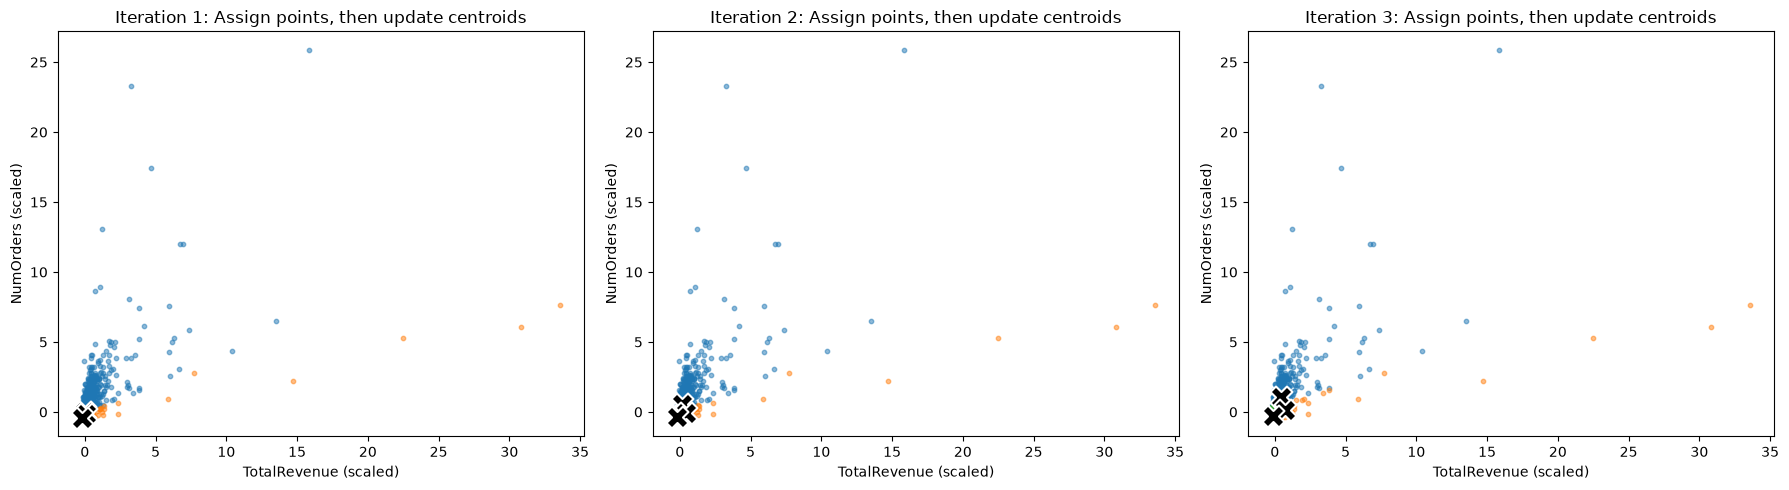

In [3]:
X_demo = X_scaled[:, [0, 1]]  # TotalRevenue vs NumOrders, scaled
rng = np.random.default_rng(42)

# Step 0: initialize centroids by picking 3 random points from the data
k = 3
initial_indices = rng.choice(len(X_demo), size=k, replace=False)
centroids = X_demo[initial_indices].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ["tab:blue", "tab:orange", "tab:green"]

for step, ax in enumerate(axes):
    # 1. Cluster Assignment: assign every point to its nearest centroid
    distances = np.linalg.norm(X_demo[:, None, :] - centroids[None, :, :], axis=2)
    assignments = np.argmin(distances, axis=1)

    for cluster_id in range(k):
        cluster_points = X_demo[assignments == cluster_id]
        ax.scatter(cluster_points[:, 0], cluster_points[:, 1], s=10, alpha=0.5, color=colors[cluster_id])
    ax.scatter(centroids[:, 0], centroids[:, 1], c="black", marker="X", s=250, edgecolors="white", linewidths=1.5)
    ax.set_title(f"Iteration {step + 1}: Assign points, then update centroids")
    ax.set_xlabel("TotalRevenue (scaled)")
    ax.set_ylabel("NumOrders (scaled)")

    # 2. Centroid Update: move each centroid to the mean of its assigned points
    centroids = np.array([X_demo[assignments == c].mean(axis=0) for c in range(k)])

plt.tight_layout()
plt.show()

## Iterations

K-Means keeps repeating Cluster Assignment and Centroid Update until the
centroids stop moving meaningfully between iterations (**convergence**),
or a maximum iteration count is hit. Each iteration should decrease (or
hold steady) the total distance between points and their assigned
centroid; below, that total distance is tracked across manual iterations
to show it settling down.

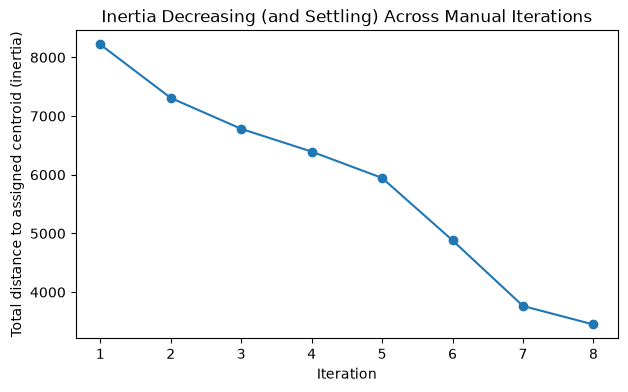

Inertia by iteration: [8219.3, 7309.0, 6782.4, 6394.0, 5945.5, 4881.6, 3763.8, 3448.3]


In [4]:
def kmeans_inertia(X, centroids, assignments):
    return sum(np.sum((X[assignments == c] - centroids[c]) ** 2) for c in range(len(centroids)))

centroids = X_demo[initial_indices].copy()
inertia_per_iteration = []

for iteration in range(8):
    distances = np.linalg.norm(X_demo[:, None, :] - centroids[None, :, :], axis=2)
    assignments = np.argmin(distances, axis=1)
    inertia_per_iteration.append(kmeans_inertia(X_demo, centroids, assignments))
    centroids = np.array([X_demo[assignments == c].mean(axis=0) for c in range(k)])

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(inertia_per_iteration) + 1), inertia_per_iteration, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Total distance to assigned centroid (inertia)")
plt.title("Inertia Decreasing (and Settling) Across Manual Iterations")
plt.show()

print("Inertia by iteration:", [round(float(v), 1) for v in inertia_per_iteration])

## Choosing K & The Elbow Method

K-Means requires the number of clusters `K` to be chosen up front — it
doesn't figure this out on its own. The **Elbow Method** is one common way
to choose it: run K-Means for a range of `K` values, record the
**inertia** (total distance from every point to its assigned centroid)
for each, and plot them. Inertia always decreases as `K` increases (more
clusters can always fit the data at least as well), but the *rate* of
improvement typically drops sharply at some point and then flattens out —
that bend is the "elbow," and it's usually a reasonable choice for `K`:
adding more clusters beyond it buys only marginal improvement.

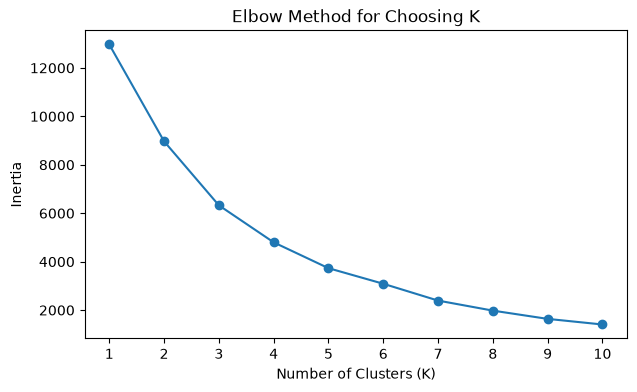

In [5]:
from sklearn.cluster import KMeans

inertias = []
k_range = range(1, 11)
for k_candidate in k_range:
    km = KMeans(n_clusters=k_candidate, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, inertias, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Choosing K")
plt.xticks(list(k_range))
plt.show()

## Silhouette Score

**What it is:** a second, complementary way to evaluate a choice of `K`
(and the actual clustering result, not just inertia). For each point, it
compares how close that point is to others *in its own cluster* versus
how close it is to points in the *nearest other* cluster, producing a
score from -1 to 1: close to 1 means the point fits well in its own
cluster and is far from other clusters (a good clustering); close to 0
means it sits right on the border between two clusters; negative means it
may have been assigned to the wrong cluster entirely. The overall
Silhouette Score is the average across all points.

Unlike inertia, the Silhouette Score doesn't automatically favor a larger
`K` — it directly rewards *well-separated, well-defined* clusters, which
makes it a useful second check alongside the Elbow Method.

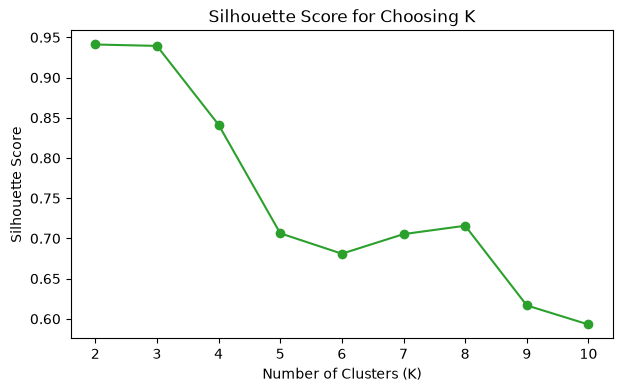

K with the highest Silhouette Score: 2


In [6]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
for k_candidate in range(2, 11):  # silhouette score needs at least 2 clusters
    km = KMeans(n_clusters=k_candidate, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(7, 4))
plt.plot(range(2, 11), silhouette_scores, marker="o", color="tab:green")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Choosing K")
plt.xticks(range(2, 11))
plt.show()

best_k = list(range(2, 11))[np.argmax(silhouette_scores)]
print("K with the highest Silhouette Score:", best_k)

## Fitting the Final Model & Visualizing the Resulting Clusters

Using the `K` selected above, the final K-Means model is fit on all three
scaled features, then visualized. Since there are 3 features (more than 2
can easily be drawn), PCA is used purely to compress them down to 2
dimensions for plotting — the clustering itself is still done on the
original, full-featured, scaled data.

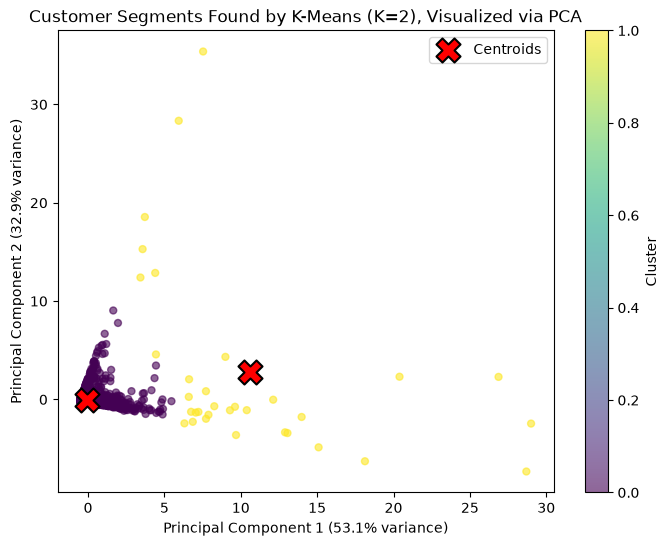

Number of customers in each cluster:
Cluster
0    4289
1      33
Name: count, dtype: int64


In [7]:
final_k = best_k
final_kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
customer_df["Cluster"] = final_kmeans.fit_predict(X_scaled)

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
centroids_pca = pca.transform(final_kmeans.cluster_centers_)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=customer_df["Cluster"], cmap="viridis", s=25, alpha=0.6)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c="red", marker="X", s=300,
           edgecolors="black", linewidths=1.5, label="Centroids")
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title(f"Customer Segments Found by K-Means (K={final_k}), Visualized via PCA")
plt.legend()
plt.colorbar(scatter, label="Cluster")
plt.show()

print("Number of customers in each cluster:")
print(customer_df["Cluster"].value_counts().sort_index())

## Cluster Interpretation

The clusters themselves are just numbers (`0`, `1`, `2`, ...) with no
inherent meaning — interpreting *what each cluster actually represents*
is a manual step that comes after fitting the model, by looking back at
the original (unscaled) feature values of the customers in each group.

In [8]:
cluster_summary = customer_df.groupby("Cluster")[feature_cols].mean().round(2)
cluster_summary["NumCustomers"] = customer_df["Cluster"].value_counts().sort_index()
cluster_summary

,TotalRevenue,NumOrders,AvgOrderValue,NumCustomers
Cluster,,,,
0,1459.98,4.64,27.30,4289
1,62164.28,66.73,544.38,33


Reading down each row of this summary table turns the abstract cluster
numbers into a real business description of that customer segment —
typically something like: one cluster of many **low-spend, infrequent**
customers, one cluster of **moderate, regular** customers, and (if
present) a small cluster of **high-value, high-frequency** customers
worth treating differently (e.g. loyalty perks or account management),
even though nobody ever told the model in advance that these categories
existed. That translation step — from "Cluster 2" to "our best
customers" — is the actual payoff of the whole clustering exercise.